In [129]:
import os
import numpy as np
import mne
import warnings
from moabb.datasets import Nakanishi2015

# Suppress standard MNE warnings for a cleaner console output
warnings.filterwarnings('ignore')

# ================= CONFIGURATION =================
SUBJECT_LIST = list(range(1, 11))  # All 10 subjects
T_MIN = 0.0             # Start epoch at stimulus onset
T_MAX = 4.0             # End epoch 4 seconds later
OUTPUT_DIR = "nakanishi_unfiltered_eeg"
# =================================================

print("1. Downloading Nakanishi 2015 Dataset...")
dataset = Nakanishi2015()
dataset.download()

# THE FIX: Dynamically ask MOABB for all available subjects
# For Nakanishi, this will automatically return[1, 2, 3, 4, 5, 6, 7, 8, 9]
SUBJECT_LIST = dataset.subject_list

print(f"   Found {len(SUBJECT_LIST)} subjects. Fetching data...")
data = dataset.get_data(subjects=SUBJECT_LIST)
freq_mapping = dataset.event_id

os.makedirs(OUTPUT_DIR, exist_ok=True)
ch_names = None

print("\n2. Extracting and saving unfiltered trials for EACH subject...")

# Iterate through every subject
for subj_id, sessions in data.items():
    print(f"\n   --- Processing Subject {subj_id} ---")

    # Create a specific folder for this subject
    subj_dir = os.path.join(OUTPUT_DIR, f"subject_{subj_id}")
    os.makedirs(subj_dir, exist_ok=True)

    # Reset the dictionary for the current subject
    trials_by_freq = {freq:[] for freq in freq_mapping.keys()}

    for session_name, session in sessions.items():
        for run_name, raw in session.items():

            raw.apply_function(lambda x: x * 1e6)
            events = mne.find_events(raw, shortest_event=1, verbose=False)

            epochs = mne.Epochs(
                raw,
                events,
                event_id=freq_mapping,
                tmin=T_MIN,
                tmax=T_MAX,
                baseline=None,
                preload=True,
                verbose=False
            )

            if ch_names is None:
                ch_names = epochs.ch_names

            for freq_str in freq_mapping.keys():
                freq_data = epochs[freq_str].get_data()
                if len(freq_data) > 0:
                    trials_by_freq[freq_str].append(freq_data)

    # 3. SAVE THIS SUBJECT'S DATA BEFORE MOVING TO THE NEXT PERSON
    for freq_str, data_list in trials_by_freq.items():
        if len(data_list) == 0:
            continue

        all_trials = np.concatenate(data_list, axis=0)

        # Save file inside the specific subject's folder
        file_path = os.path.join(subj_dir, f"{freq_str}hz.npy")
        np.save(file_path, all_trials)

        print(f"   Saved {freq_str:>5} Hz -> Shape: {all_trials.shape} -> {file_path}")

# Save the channel names in the main directory
np.save(os.path.join(OUTPUT_DIR, "channel_names.npy"), ch_names)
print(f"\nChannel names saved: {ch_names}")
print("Extraction Complete! Data is safely separated by subject.")

1. Downloading Nakanishi 2015 Dataset...
   Found 9 subjects. Fetching data...


Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data



2. Extracting and saving unfiltered trials for EACH subject...

   --- Processing Subject 1 ---
   Saved  9.25 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\9.25hz.npy
   Saved 11.25 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\11.25hz.npy
   Saved 13.25 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\13.25hz.npy
   Saved  9.75 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\9.75hz.npy
   Saved 11.75 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\11.75hz.npy
   Saved 13.75 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\13.75hz.npy
   Saved 10.25 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\10.25hz.npy
   Saved 12.25 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\12.25hz.npy
   Saved 14.25 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject_1\14.25hz.npy
   Saved 10.75 Hz -> Shape: (15, 9, 1025) -> nakanishi_unfiltered_eeg\subject

In [136]:
import os
import numpy as np
import random
from scipy import signal
from sklearn.cross_decomposition import CCA

# ================= CONFIGURATION =================
DATA_DIR = "nakanishi_unfiltered_eeg"
FS = 256.0
WINDOW_SEC = 3.0
ITERATIONS_PER_FREQ = 100  # Monte Carlo iterations per class

TARGET_FREQS =[9.25, 9.75, 10.25, 10.75, 11.25, 11.75,
                12.25, 12.75, 13.25, 13.75, 14.25, 14.75]

# Subjects 1 through 9 (Since Subject 10 is missing from the dataset)
SUBJECT_LIST = list(range(1, 10))

# Channels 0 through 7 are the visual cortex. Channel 8 is 'stim'.
USEFUL_CHANNELS = slice(0, 8)
# =================================================

window_samples = int(WINDOW_SEC * FS)

print("1. Pre-computing pure Sine/Cosine templates (Speed Optimization)...")
time_array = np.arange(0, window_samples) / FS
reference_templates = {}

for freq in TARGET_FREQS:
    reference_signals =[]
    # Using 3 harmonics (1x, 2x, 3x)
    for harmonic in [1, 2, 3]:
        reference_signals.append(np.sin(2 * np.pi * freq * harmonic * time_array))
        reference_signals.append(np.cos(2 * np.pi * freq * harmonic * time_array))
    # Save the transposed shape (Samples, 6 Template Signals)
    reference_templates[freq] = np.array(reference_signals).T

print(f"2. Running Monte Carlo Simulation ({ITERATIONS_PER_FREQ} tests per frequency, per subject)...\n")

# Create the bandpass filter (6 Hz to 80 Hz)
b, a = signal.butter(4,[6.0, 80.0], btype='bandpass', fs=FS)
cca = CCA(n_components=1)

# To store all results for the final leaderboard
global_results = {}

# =================================================
# NEW OUTER LOOP: Iterate through each subject
# =================================================
for subj_id in SUBJECT_LIST:
    subj_dir = os.path.join(DATA_DIR, f"subject_{subj_id}")

    if not os.path.exists(subj_dir):
        print(f"Skipping Subject {subj_id} - folder not found: {subj_dir}")
        continue

    print(f"================ SUBJECT {subj_id} ================")
    print(f"{'Target Freq':<15} | {'Accuracy (%)':<15} | {'Correct / Total'}")
    print("-" * 55)

    total_correct_subj = 0
    total_tests_subj = 0
    global_results[subj_id] = {}

    for true_freq in TARGET_FREQS:
        # Update path to look inside the specific subject's folder
        file_path = os.path.join(subj_dir, f"{true_freq}hz.npy")

        if not os.path.exists(file_path):
            print(f"{true_freq:>5.2f} Hz{'':<7} | {'MISSING':<15} | N/A")
            continue

        # Load data: Shape is (Trials, 9 Channels, 1024 Samples)
        raw_data = np.load(file_path)

        # 1. SLICE OUT THE 'STIM' CHANNEL
        brain_data = raw_data[:, USEFUL_CHANNELS, :]

        # 2. FILTER ALL TRIALS AT ONCE
        filtered_data = signal.filtfilt(b, a, brain_data, axis=2)

        total_trials = filtered_data.shape[0]
        total_samples = filtered_data.shape[2]
        max_start_idx = total_samples - window_samples

        correct_predictions = 0

        # 3. MONTE CARLO LOOP
        for _ in range(ITERATIONS_PER_FREQ):
            # Pick random trial and random start time
            random_trial_idx = random.randint(0, total_trials - 1)
            random_start_idx = random.randint(0, max_start_idx)

            # Extract the 2-second snippet -> Shape: (8, 512)
            snippet = filtered_data[random_trial_idx, :, random_start_idx : random_start_idx + window_samples]

            # Transpose for Sklearn -> Shape: (512, 8)
            eeg_signal = snippet.T

            # CCA Classification against all 12 templates
            best_score = -1.0
            predicted_freq = None

            for test_freq, Y_template in reference_templates.items():
                X_c, Y_c = cca.fit_transform(eeg_signal, Y_template)
                score = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

                if score > best_score:
                    best_score = score
                    predicted_freq = test_freq

            # Check if the BCI correctly guessed the command
            if predicted_freq == true_freq:
                correct_predictions += 1

        # Calculate and store accuracy for this specific frequency
        accuracy = (correct_predictions / ITERATIONS_PER_FREQ) * 100
        global_results[subj_id][true_freq] = accuracy

        total_correct_subj += correct_predictions
        total_tests_subj += ITERATIONS_PER_FREQ

        print(f"{true_freq:>5.2f} Hz{'':<7} | {accuracy:>7.2f}%{'':<7} | {correct_predictions:>4} / {ITERATIONS_PER_FREQ}")

    # Calculate overall accuracy for this subject
    if total_tests_subj > 0:
        overall_subj_acc = (total_correct_subj / total_tests_subj) * 100
        print("-" * 55)
        print(f"SUBJECT {subj_id} OVERALL ACCURACY: {overall_subj_acc:.2f}%\n")
        global_results[subj_id]['OVERALL'] = overall_subj_acc


# =================================================
# PRINT THE FINAL LEADERBOARD
# =================================================
print("\n================= PILOT LEADERBOARD =================")
print(f"{'Subject':<10} | {'Overall Drone Accuracy':<25}")
print("-" * 50)

# Sort subjects by their overall accuracy (highest to lowest)
sorted_subjects = sorted(global_results.items(), key=lambda item: item[1].get('OVERALL', 0), reverse=True)

for subj_id, results in sorted_subjects:
    acc = results.get('OVERALL', 0.0)
    print(f"Subject {subj_id:<2} | {acc:.2f}%")
print("=====================================================\n")

1. Pre-computing pure Sine/Cosine templates (Speed Optimization)...
2. Running Monte Carlo Simulation (100 tests per frequency, per subject)...

================ SUBJECT 1 ================
Target Freq     | Accuracy (%)    | Correct / Total
-------------------------------------------------------
 9.25 Hz        |   79.00%        |   79 / 100
 9.75 Hz        |  100.00%        |  100 / 100
10.25 Hz        |   94.00%        |   94 / 100
10.75 Hz        |   75.00%        |   75 / 100
11.25 Hz        |   63.00%        |   63 / 100
11.75 Hz        |   48.00%        |   48 / 100
12.25 Hz        |   26.00%        |   26 / 100
12.75 Hz        |    0.00%        |    0 / 100
13.25 Hz        |   26.00%        |   26 / 100
13.75 Hz        |   48.00%        |   48 / 100
14.25 Hz        |   51.00%        |   51 / 100
14.75 Hz        |   49.00%        |   49 / 100
-------------------------------------------------------
SUBJECT 1 OVERALL ACCURACY: 54.92%

================ SUBJECT 2 ================
Tar

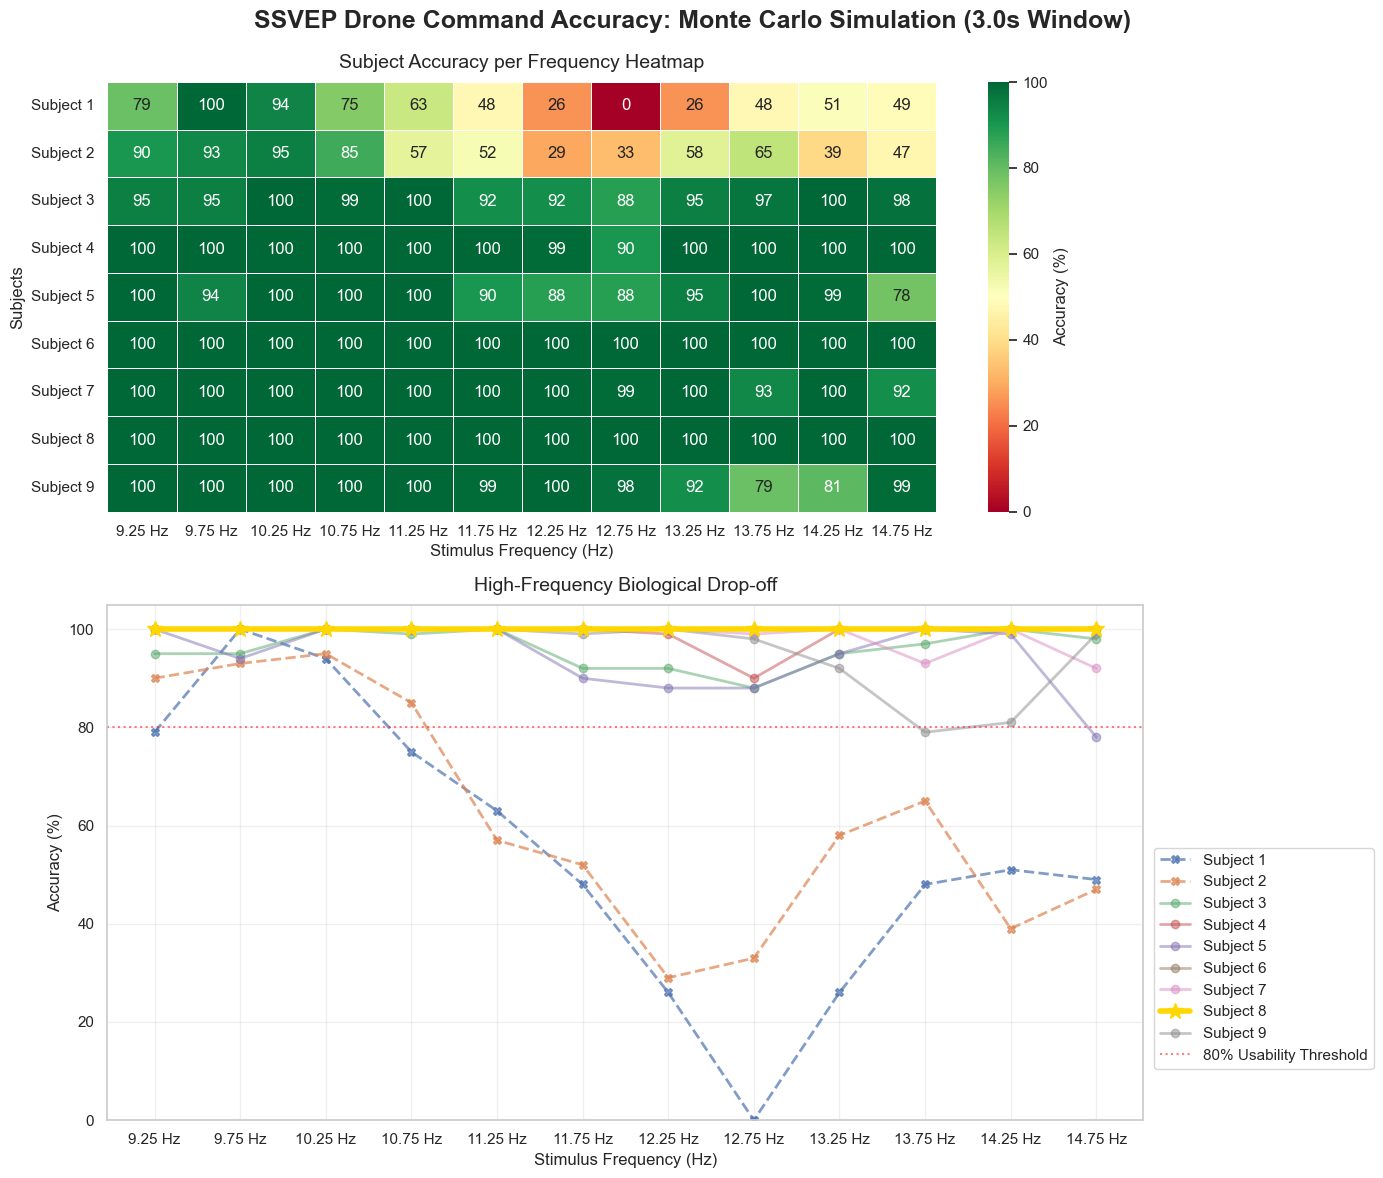

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. The data you just generated (Hardcoded so you don't have to rerun the sim)
frequencies =["9.25 Hz", "9.75 Hz", "10.25 Hz", "10.75 Hz", "11.25 Hz", "11.75 Hz",
               "12.25 Hz", "12.75 Hz", "13.25 Hz", "13.75 Hz", "14.25 Hz", "14.75 Hz"]

data = {
    'Subject 1':[79, 100, 94, 75, 63, 48, 26, 0, 26, 48, 51, 49],
    'Subject 2':[90, 93, 95, 85, 57, 52, 29, 33, 58, 65, 39, 47],
    'Subject 3':[95, 95, 100, 99, 100, 92, 92, 88, 95, 97, 100, 98],
    'Subject 4':[100, 100, 100, 100, 100, 100, 99, 90, 100, 100, 100, 100],
    'Subject 5':[100, 94, 100, 100, 100, 90, 88, 88, 95, 100, 99, 78],
    'Subject 6':[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100],
    'Subject 7':[100, 100, 100, 100, 100, 100, 100, 99, 100, 93, 100, 92],
    'Subject 8':[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100],
    'Subject 9':[100, 100, 100, 100, 100, 99, 100, 98, 92, 79, 81, 99]
}

# Convert to a Pandas DataFrame for easy plotting
df = pd.DataFrame(data, index=frequencies).T

# Set up the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1.2]})
fig.suptitle('SSVEP Drone Command Accuracy: Monte Carlo Simulation (3.0s Window)', fontsize=18, fontweight='bold')

# ==========================================
# PLOT 1: THE ACCURACY HEATMAP
# ==========================================
# A heatmap is perfect for seeing the "sweet spots" and identifying BCI illiteracy
sns.heatmap(df, annot=True, cmap='RdYlGn', fmt='g', ax=axes[0], vmin=0, vmax=100,
            cbar_kws={'label': 'Accuracy (%)'}, linewidths=.5)

axes[0].set_title('Subject Accuracy per Frequency Heatmap', fontsize=14, pad=10)
axes[0].set_ylabel('Subjects', fontsize=12)
axes[0].set_xlabel('Stimulus Frequency (Hz)', fontsize=12)

# ==========================================
# PLOT 2: LINE PLOT (FREQUENCY DROP-OFF)
# ==========================================
# Line plots easily show how the brain struggles with higher frequencies
x_numeric = np.arange(len(frequencies))

# Plot each subject
for index, row in df.iterrows():
    # Make Subject 8 a thick gold line to highlight your "Best Pilot"
    if index == 'Subject 8':
        axes[1].plot(x_numeric, row, marker='*', markersize=12, linewidth=4, label=f"{index}", color='#FFD700', zorder=10)
    # Highlight the BCI illiterate subjects in red dashes
    elif index in ['Subject 1', 'Subject 2']:
        axes[1].plot(x_numeric, row, marker='X', linestyle='--', linewidth=2, label=f"{index}", alpha=0.7)
    else:
        axes[1].plot(x_numeric, row, marker='o', linewidth=2, label=index, alpha=0.5)

axes[1].set_title('High-Frequency Biological Drop-off', fontsize=14, pad=10)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_xlabel('Stimulus Frequency (Hz)', fontsize=12)
axes[1].set_xticks(x_numeric)
axes[1].set_xticklabels(frequencies)
axes[1].set_ylim(0, 105)
axes[1].axhline(y=80, color='red', linestyle=':', alpha=0.5, label='80% Usability Threshold')

# Put the legend outside the graph
axes[1].legend(loc='lower left', bbox_to_anchor=(1.01, 0.1), borderaxespad=0)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjust title spacing

# Save it as a high-res image and display it!
plt.savefig('drone_bci_accuracy_report.png', dpi=300, bbox_inches='tight')
plt.show()